# Notebook 02b: Appendix Diagnostics and Extension Scaffold

I ran several diagnostics that support Notebook 02 or scaffold a named future extension. However, these results are less significant and so just reported for completeness.

Notebook 02 asked: does M2 growth this year predict inflation this year?
02b asks: does M2 growth from 1 or 2 years ago also predict inflation today? Maybe the effect comes with a delay.  

## Targets

- Distributed-lag estimates are reduced-form associations, not causal impulse responses.

In [ ]:
## common imports and setup for all notebooks
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from linearmodels.panel import PanelOLS

warnings.filterwarnings("ignore")


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "02_data/analysis_ready/macro_growth_merged.csv").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root from current working directory")


ROOT = find_project_root(Path.cwd().resolve())
PANEL_PATH = ROOT / "02_data/analysis_ready/macro_growth_merged.csv"
FIG_DIR = ROOT / "04_current_results/figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

if not PANEL_PATH.exists():
    raise FileNotFoundError(f"Missing required file: {PANEL_PATH}")
ROOT

PosixPath('/Users/stevenchung/Desktop/P12B_File/Monetary_Panel')

### Load panel and helpers


In [ ]:
panel = (
    pd.read_csv(PANEL_PATH)
    .rename(columns={"Country Name": "country"})
    .sort_values(["country", "year"])
    .copy()
)

def fit_inflation_twfe(df, cov_type="clustered", **fit_kwargs):
    if cov_type == "clustered" and not fit_kwargs:
        fit_kwargs = {"cluster_entity": True}
    fit_df = df.dropna(subset=["inflation", "m2_growth"]).set_index(["country", "year"]).sort_index()
    formula = "inflation ~ 1 + m2_growth + EntityEffects + TimeEffects"
    return PanelOLS.from_formula(formula, data=fit_df).fit(cov_type=cov_type, **fit_kwargs)


clean_panel = panel[panel["sample_low_inflation"] == 1].copy()

### Distributed-lag scaffold: cumulative association

This block estimates contemporaneous and lagged associations of M2 growth with inflation using entity and year fixed effects.

The relationship is not causal.


In [3]:
lag = panel[panel["sample_main"] == 1].copy().sort_values(["country", "year"])
lag["m2_l1"] = lag.groupby("country")["m2_growth"].shift(1)
lag["m2_l2"] = lag.groupby("country")["m2_growth"].shift(2)
lag = lag.dropna(subset=["m2_growth", "m2_l1", "m2_l2", "inflation"])
lag_panel = lag.set_index(["country", "year"])

lag_res = PanelOLS.from_formula(
    "inflation ~ m2_growth + m2_l1 + m2_l2 + EntityEffects + TimeEffects",
    data=lag_panel,
    drop_absorbed=True,
).fit(cov_type="clustered", cluster_entity=True)

terms = ["m2_growth", "m2_l1", "m2_l2"]
term_table = pd.DataFrame({
    "term": terms,
    "coef": [float(lag_res.params[t]) for t in terms],
    "se": [float(lag_res.std_errors[t]) for t in terms],
    "p_value": [float(lag_res.pvalues[t]) for t in terms],
})

cov = lag_res.cov.loc[terms, terms].to_numpy()
beta = lag_res.params.loc[terms].to_numpy()
weights = {
    "h0": np.array([1.0, 0.0, 0.0]),
    "h0_plus_h1": np.array([1.0, 1.0, 0.0]),
    "h0_plus_h1_plus_h2": np.array([1.0, 1.0, 1.0]),
}

cum_rows = []
for label, w in weights.items():
    est = float(w @ beta)
    se = float(np.sqrt(w @ cov @ w))
    cum_rows.append({
        "cumulative_horizon": label,
        "estimate": est,
        "se": se,
        "ci_low_95": est - 1.96 * se,
        "ci_high_95": est + 1.96 * se,
    })

cum_table = pd.DataFrame(cum_rows)
display(term_table)
display(cum_table)


,term,coef,se,p_value
0,m2_growth,0.481198,0.085367,1.845069e-08
1,m2_l1,0.295704,0.024470,0.000000e+00
2,m2_l2,0.104159,0.041013,1.113182e-02


,cumulative_horizon,estimate,se,ci_low_95,ci_high_95
0,h0,0.481198,0.085367,0.313878,0.648518
1,h0_plus_h1,0.776902,0.078859,0.622338,0.931466
2,h0_plus_h1_plus_h2,0.881061,0.095485,0.693911,1.068212


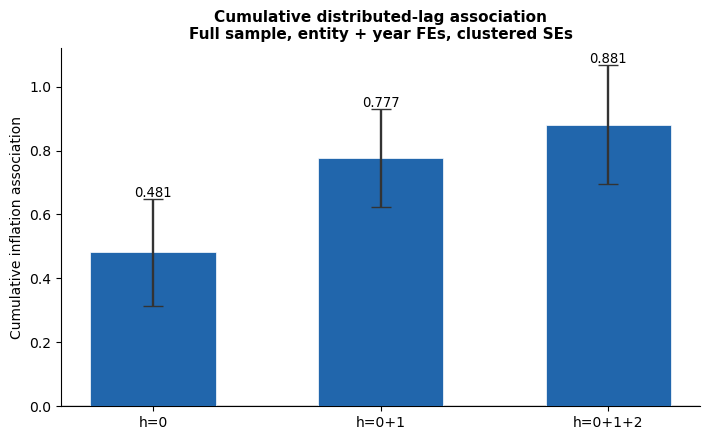

In [4]:
fig, ax = plt.subplots(figsize=(7.2, 4.5))
x = np.arange(len(cum_table))
labels = ["h=0", "h=0+1", "h=0+1+2"]

ax.bar(x, cum_table["estimate"], color="#2166ac", width=0.55, edgecolor="white", lw=0.5, zorder=3)
ax.errorbar(
    x,
    cum_table["estimate"],
    yerr=1.96 * cum_table["se"],
    fmt="none",
    color="#333333",
    capsize=7,
    lw=1.7,
    zorder=4,
)
ax.axhline(0, color="black", lw=0.9)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Cumulative inflation association")
ax.set_title(
    "Cumulative distributed-lag association\nFull sample, entity + year FEs, clustered SEs",
    fontsize=11,
    fontweight="bold",
)
for i, row in cum_table.iterrows():
    ax.text(i, row["estimate"] + 1.96 * row["se"] + 0.005, f"{row['estimate']:.3f}", ha="center", fontsize=9.5)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
fig.savefig(FIG_DIR / "distributed_lag_cumulative_association.png", dpi=150, bbox_inches="tight")
plt.show()
